In [1]:
import pickle

import torch
from torchmetrics.functional import pairwise_cosine_similarity
from transformers import AutoTokenizer
from transformers import T5EncoderModel


In [2]:


def get_tac_encodings(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor, tactic_lens
) -> torch.FloatTensor:
    # encode all tokens with tactic included
    combined_enc = encoder(input_ids, attention_mask, return_dict=True).last_hidden_state

    # get the tactic embeddings and mean pool them using the provided lengths
    tac_enc = []

    for i in range(combined_enc.shape[0]):
        enc = combined_enc[i, :tactic_lens[i]]
        enc = enc.sum(dim=0) / tactic_lens[i]
        enc = F.normalize(enc, dim=0)
        tac_enc.append(enc)

    tac_enc = torch.stack(tac_enc, dim=0).unsqueeze(1)
    return tac_enc


def get_vecs(encoder, tactics, goal, theorem):
    state = goal.data['augmented_state'] if hasattr(goal, 'data') and 'augmented_state' in goal.data else goal.goal

    encs = []

    # todo chunk into batches enc speedup
    for t in tactics:
        goal = [t + theorem + '\n\n' + state]

        tokenized_goals = tokenizer(
            goal,
            padding="longest",
            max_length=int(3000),
            truncation=True,
            return_tensors="pt", )

        tokenized_tactics = tokenizer(
            tactics,
            padding="longest",
            max_length=3000,
            truncation=True,
            return_tensors="pt",
        )

        lens = tokenized_tactics.attention_mask.sum(dim=1)

        enc = get_tac_encodings(encoder, tokenized_goals.input_ids.cuda(), tokenized_goals.attention_mask.cuda(), lens.cuda())

        # scale enc by normalised tactic logprob
        # enc = enc * probs[tactics.index(t)]
        encs.append(enc.squeeze(0).squeeze(0))

    return torch.stack(encs, dim=0)


In [3]:

import torch.nn.functional as F


def _encode(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor
) -> torch.FloatTensor:
    hidden_states = encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    ).last_hidden_state

    # Masked average.
    lens = attention_mask.sum(dim=1)
    features = (hidden_states * attention_mask.unsqueeze(2)).sum(
        dim=1
    ) / lens.unsqueeze(1)

    # Normalize the feature vector to have unit norm.
    return F.normalize(features, dim=1)


In [4]:

def plot(start, end, sims):
    # Convert the tensor to a NumPy array
    similarity_matrix_np = sims.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np, xticklabels=names, yticklabels=names, annot=True, cmap='viridis')

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add labels and title
    plt.xlabel('Vectors')
    plt.ylabel('Vectors')
    plt.title('Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()
   

In [83]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_overlay(start, end, sims1, sims2):
    # Convert the tensors to NumPy arrays
    similarity_matrix_np1 = sims1.cpu().detach().numpy()[start:end, start:end]
    similarity_matrix_np2 = sims2.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]
    
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np1, xticklabels=names, yticklabels=names, annot=False, cmap='viridis', cbar=False)
    sns.heatmap(similarity_matrix_np2, xticklabels=names, yticklabels=names, annot=False, cmap='viridis', cbar=True, ax=ax)
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add diagonal splits and annotations
    for i in range(len(names)):
        for j in range(len(names)):
            value1 = similarity_matrix_np1[i, j]
            value2 = similarity_matrix_np2[i, j]
            
            # Add diagonal line
            # ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, color='blue', alpha=0.3))
            # ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True, color='red', alpha=0.3))

            ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, facecolor=plt.cm.viridis(value1), alpha=0.3))
            ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True,facecolor=plt.cm.viridis(value2), alpha=0.3))
            # Add annotations
            ax.text(j + 0.25, i + 0.25, f'{value1:.2f}', ha='center', va='center', fontsize=8, color='white')
            ax.text(j + 0.75, i + 0.75, f'{value2:.2f}', ha='center', va='center', fontsize=8, color='white')
    
    # Add labels and title
    plt.xlabel('Tactic')
    plt.ylabel('Tactic')
    plt.title('Overlay Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()

# Example usage
# plot_overlay(start, end, sims1, sims2)


In [6]:
# ckpt_path = '../runs/diversity/with_tac/2024_07_05/16_34/checkpoints/tac_enc'

# combined_encoder_path = '../runs/diversity/large-single-vec-2/2024_07_15/10_57/checkpoints/combined_enc.ckpt'
# separate_encoder_path = '../runs/separate_tac_encoder/checkpoints/separate_encoder.ckpt'

combined_encoder_path = '../runs/diversity/large-single-vec-2/2024_07_15/10_57/checkpoints/combined_last.ckpt'

separate_encoder_path = '../runs/separate_tac_encoder/checkpoints/separate_last.ckpt'

autoenc_path = '../runs/diversity/autoencoder/2024_07_18/12_13/checkpoints/autoencoder.ckpt'


ckpt = torch.load(combined_encoder_path)
state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

tokenizer = AutoTokenizer.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises')

combined_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                                  state_dict=state_dict).cuda()


ckpt = torch.load(separate_encoder_path)

state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

separate_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                                  state_dict=state_dict).cuda()


ckpt = torch.load(autoenc_path)

state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

autoencoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                                  state_dict=state_dict).cuda()



Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [106]:

# good example with node 0
test_trace = "../runs/bestfs-novel-2/convex.finsum_mem"

# test_trace = "../runs/bestfs-novel-2/cau_seq.lim_inv"

trace = pickle.load(open(test_trace, 'rb'))
nodes = list(trace.nodes.values())

In [107]:
node = nodes[0]
tacs = [e.tactic for e in node.out_edges]
theorem = trace.theorem.full_name

with torch.no_grad():
    combined_encs = get_vecs(combined_encoder, tacs, node, theorem)

with torch.no_grad():
    tokenized_tacs = [tokenizer( e,
                                padding="longest",
                                max_length=2300,
                                truncation=True,
                                return_tensors="pt") for e in tacs]


    lens = [tokenized_tactic.attention_mask.sum(dim=1) for tokenized_tactic in tokenized_tacs]


    vecs = [_encode(separate_encoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]
    separate_encs = torch.stack(vecs)

    autoencs = [_encode(autoencoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]
    autoencs = torch.stack(autoencs)

separate_cosine_sim = pairwise_cosine_similarity(separate_encs)
combined_cosine_sim = pairwise_cosine_similarity(combined_encs)
autoencsim = pairwise_cosine_similarity(autoencs)


In [108]:
start = 0
end = 15

lemma <a>smul_le_smul_of_nonneg</a> (h₁ : a ≤ b) (h₂ : 0 ≤ c) : c • a ≤ c • b

@[simp, to_additive] lemma <a>smul_eq_mul</a> (α : Type*) [has_mul α] {a a' : α} : a • a' = a * a'

@[to_additive]
lemma <a>set.mem_smul_set_iff_inv_smul_mem</a> : x ∈ a • A ↔ a⁻¹ • x ∈ A

@[to_additive]
lemma <a>set.mem_inv_smul_set_iff</a> : x ∈ a⁻¹ • A ↔ a • x ∈ A

@[to_additive] lemma <a>set.mem_smul_set</a> : x ∈ a • t ↔ ∃ y, y ∈ t ∧ a • y = x

@[to_additive] lemma <a>set.smul_mem_smul_set</a> : b ∈ s → a • b ∈ a • s

@[to_additive] lemma <a>smul_smul</a> (a₁ a₂ : M) (b : α) : a₁ • a₂ • b = (a₁ * a₂) • b

lemma <a>inv_smul_le_iff</a> (h : 0 < c) : c⁻¹ • a ≤ b ↔ a ≤ c • b

lemma <a>smul_le_smul_iff_of_pos</a> (hc : 0 < c) : c • a ≤ c • b ↔ a ≤ b

@[simp] lemma <a>smul_eq_zero</a> : c • x = 0 ↔ c = 0 ∨ x = 0

@[simp] lemma <a>set.smul_mem_smul_set_iff₀</a> (ha : a ≠ 0) (A : set β)
  (x : β) : a • x ∈ a • A ↔ x ∈ A

theorem <a>submodule.smul_mem_iff</a> (s0 : s ≠ 0) : s • x ∈ p ↔ x ∈ p

lemma <a>smul_right

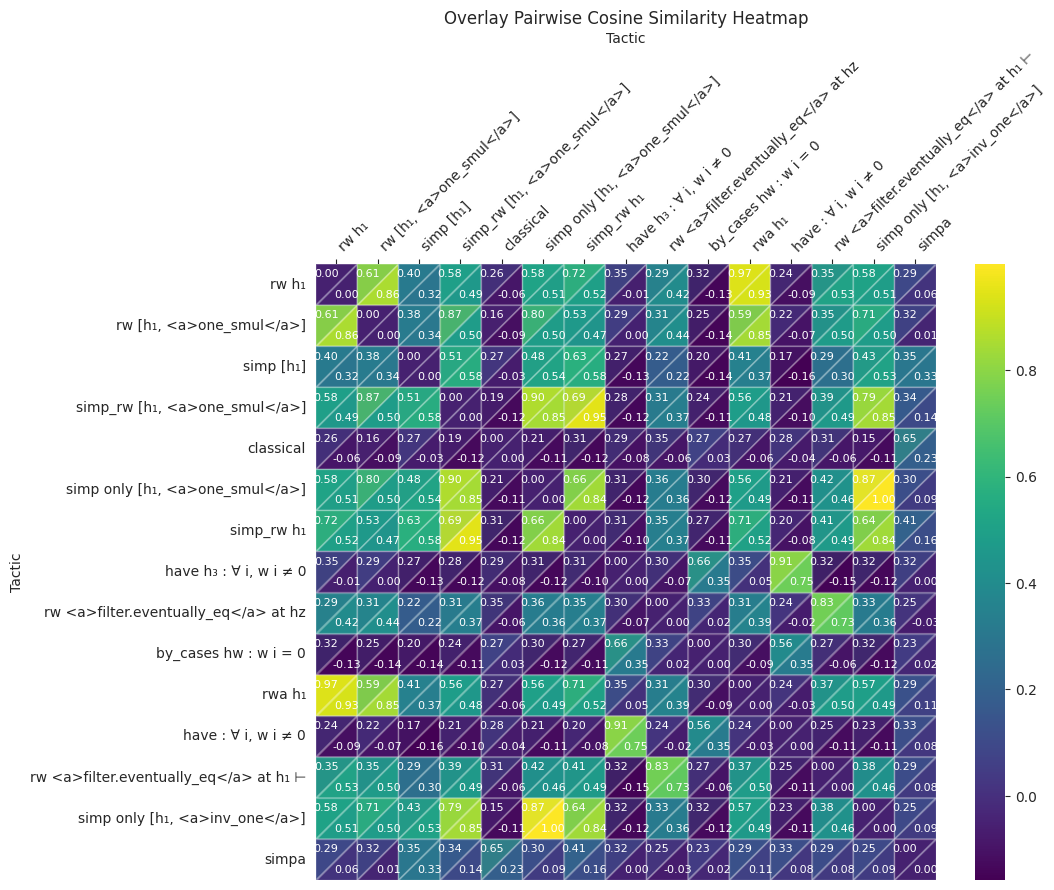

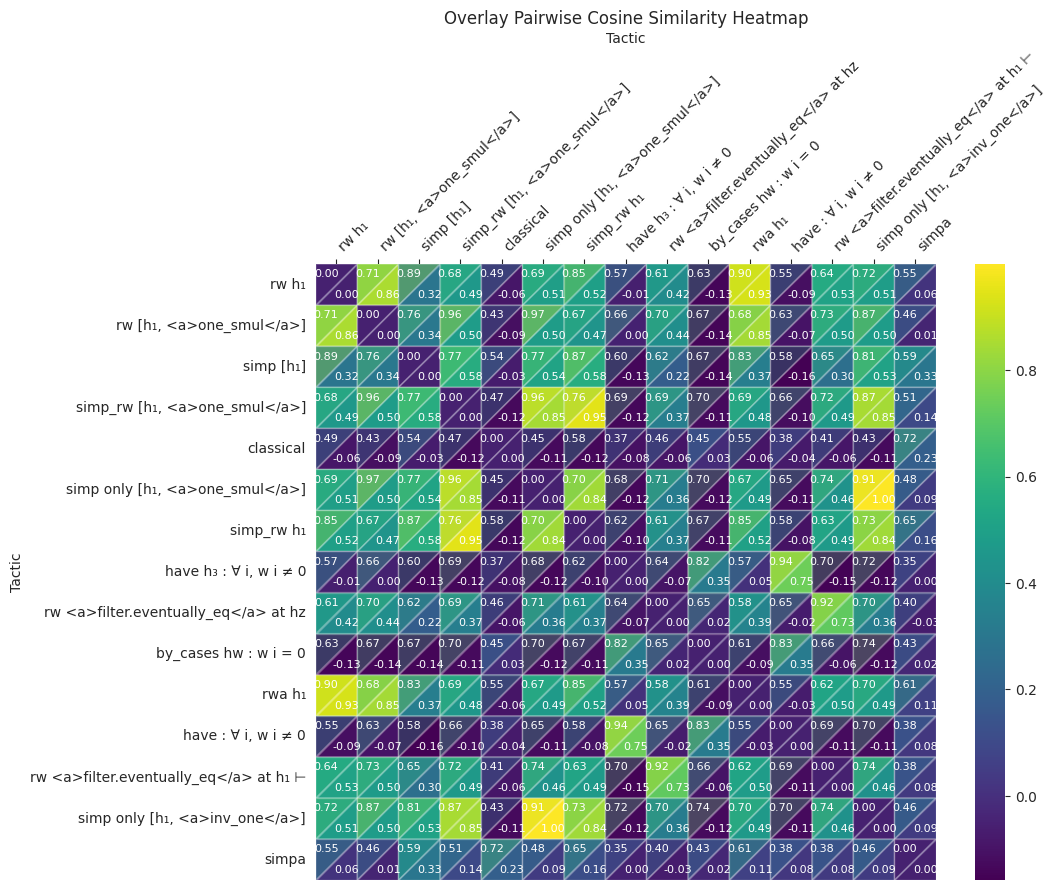

In [109]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

lemma <a>continuous_const</a> {b : β} : continuous (λa:α, b)

def <a>is_preconnected</a> (s : set α) : Prop :=
∀ (u v : set α), is_open u → is_open v → s ⊆ u ∪ v →
  (s ∩ u).nonempty → (s ∩ v).nonempty → (s ∩ (u ∩ v)).nonempty

lemma <a>path_connected_space_iff_eq</a> : path_connected_space X ↔ ∃ x : X, path_component x = univ

lemma <a>loc_path_connected_of_is_open</a> [loc_path_connected_space X] {U : set X} (h : is_open U) :
  loc_path_connected_space U

lemma <a>path_connected_space_iff_connected_space</a> [loc_path_connected_space X] :
  path_connected_space X ↔ connected_space X

lemma <a>subtype.preconnected_space</a> {s : set α} (h : is_preconnected s) :
  preconnected_space s

lemma <a>is_preconnected_iff_preconnected_space</a> {s : set α} :
  is_preconnected s ↔ preconnected_space s

class <a>path_connected_space</a> (X : Type*) [topological_space X] : Prop :=
(nonempty : nonempty X)
(joined : ∀ x y : X, joined x y)

lemma <a>real.convex_iff_is_preconnected</a> {s : set ℝ} : 

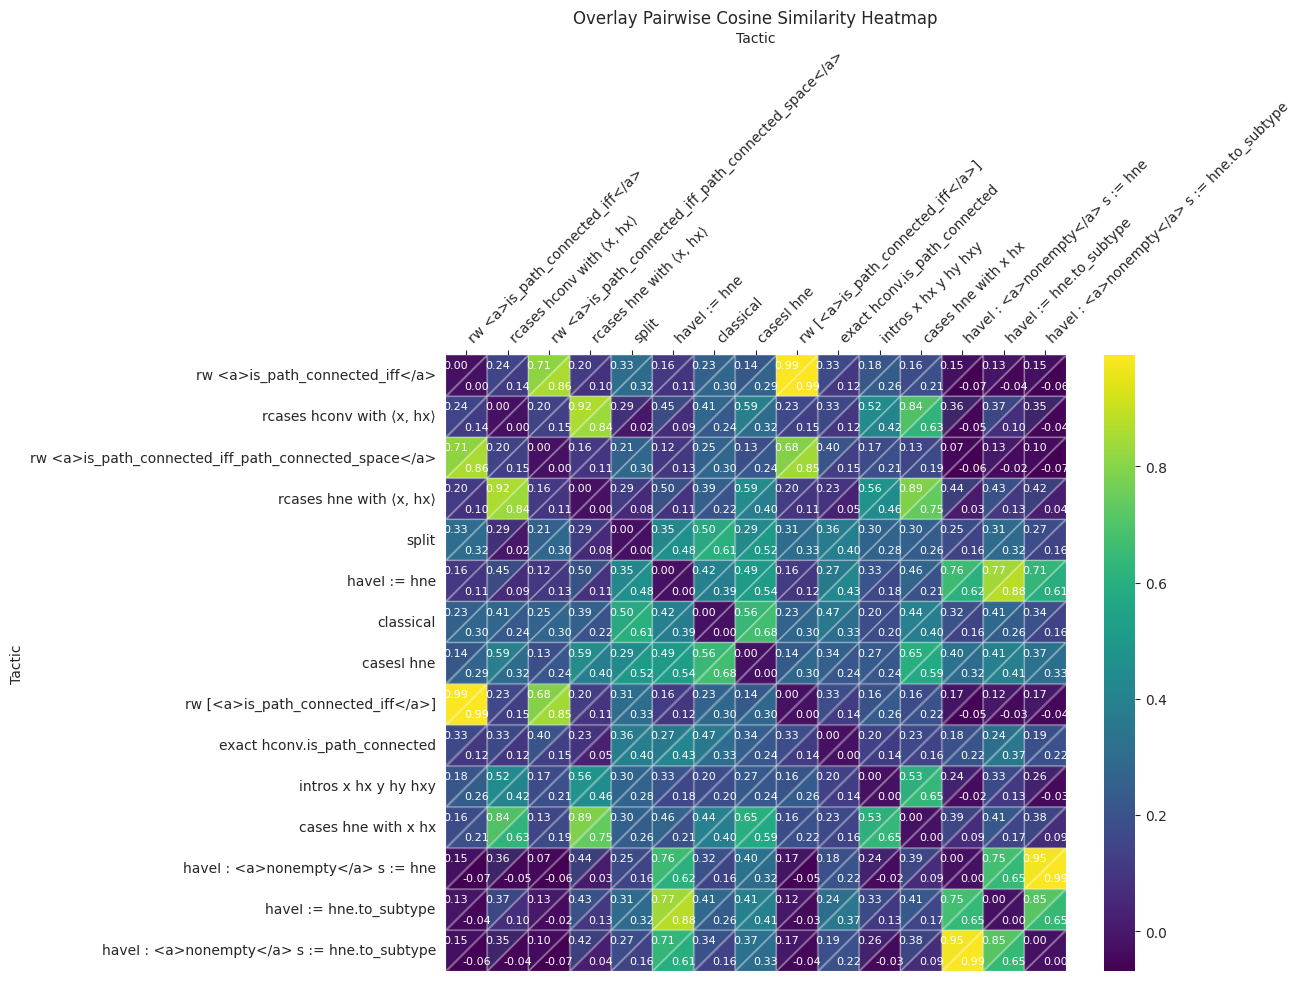

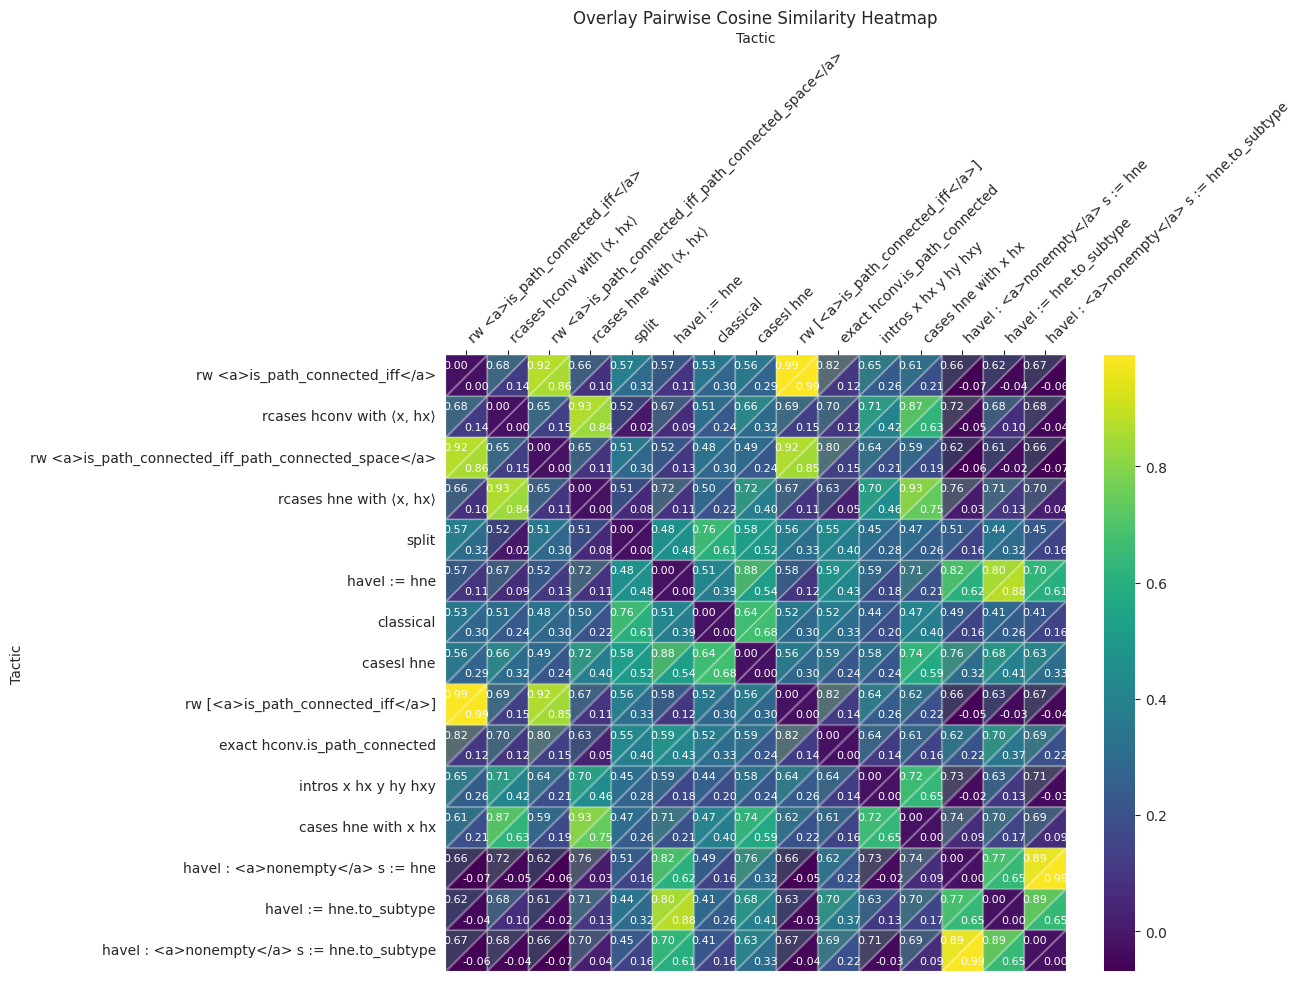

In [105]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

lemma <a>le_or_lt</a> (a b : α) : a ≤ b ∨ b < a

lemma <a>cardinal.mk_eq_one</a> (α : Type u) [unique α] : #α = 1

@[simp] lemma <a>order.lt_succ_iff</a> : a < succ b ↔ a ≤ b

lemma <a>order.le_succ</a> : ∀ a : α, a ≤ succ a

lemma <a>order.le_of_lt_succ</a> {a b : α} : a < succ b → a ≤ b

@[simp] theorem <a>cardinal.lift_id</a> (a : cardinal) : lift.{u u} a = a

lemma <a>order.succ_le_of_lt</a> {a b : α} : a < b → succ a ≤ b

@[simp] theorem <a>cardinal.lift_zero</a> : lift 0 = 0

theorem <a>one_le_pow_of_one_le</a> (H : 1 ≤ a) : ∀ (n : ℕ), 1 ≤ a ^ n

@[simp] theorem <a>cardinal.lift_le</a> {a b : cardinal} : lift a ≤ lift b ↔ a ≤ b

theorem <a>function.iterate_zero_apply</a> (x : α) : f^[0] x = x

@[simp] lemma <a>order.succ_le_iff</a> : succ a ≤ b ↔ a < b

@[simp] theorem <a>function.iterate_zero</a> : f^[0] = id

@[simp] theorem <a>cardinal.lift_one</a> : lift 1 = 1

@[simp] theorem <a>cardinal.mk_def</a> (α : Type u) : @eq cardinal ⟦α⟧ (#α)

@[elab_as_eliminator]
lemma <a>cardinal

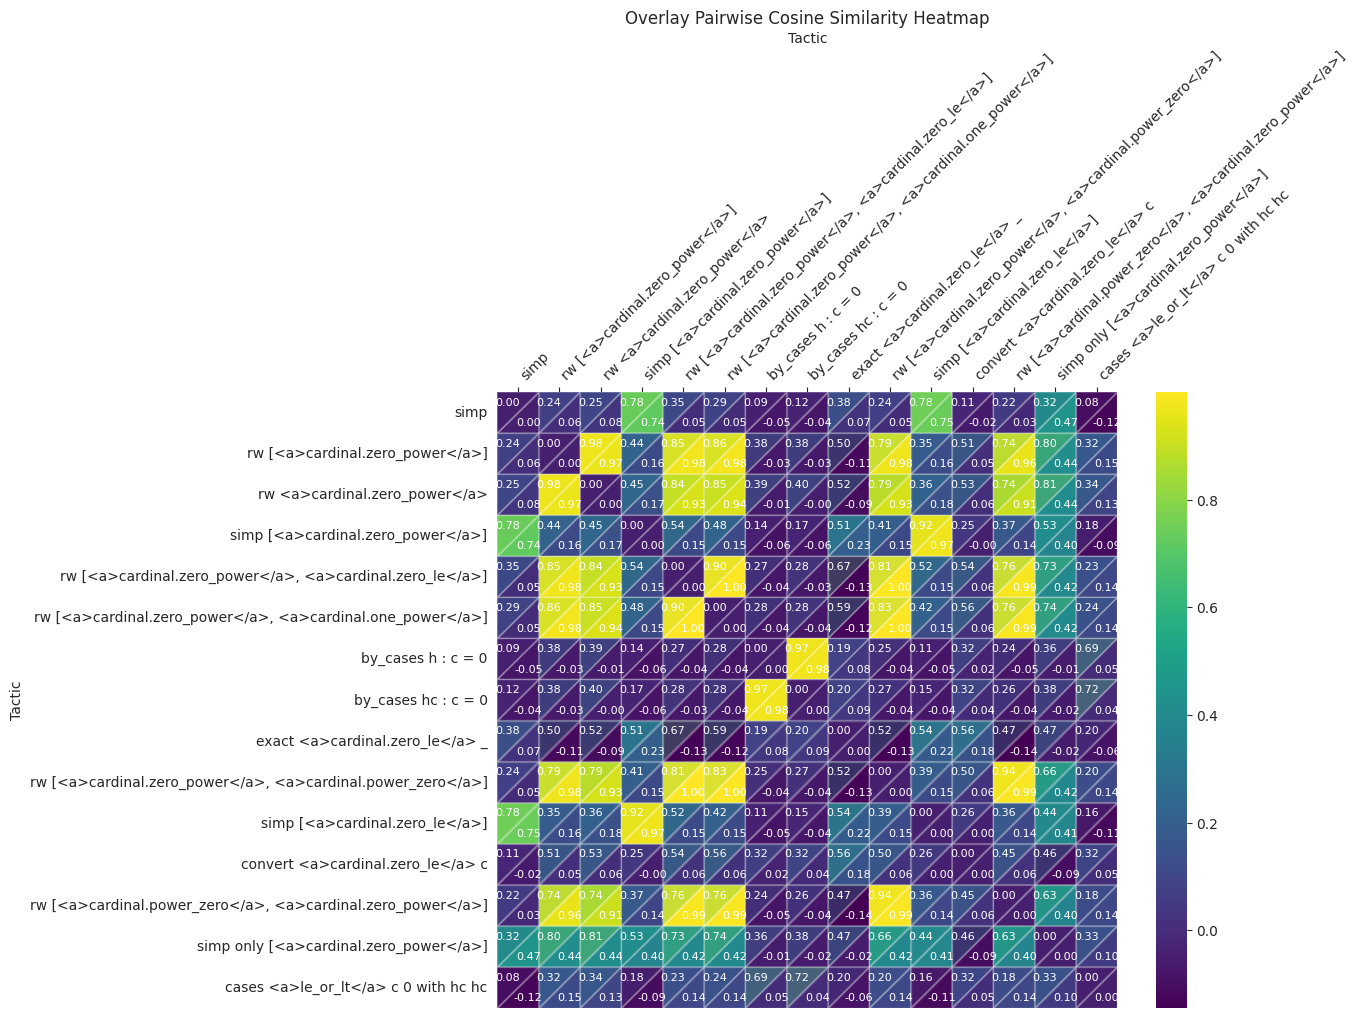

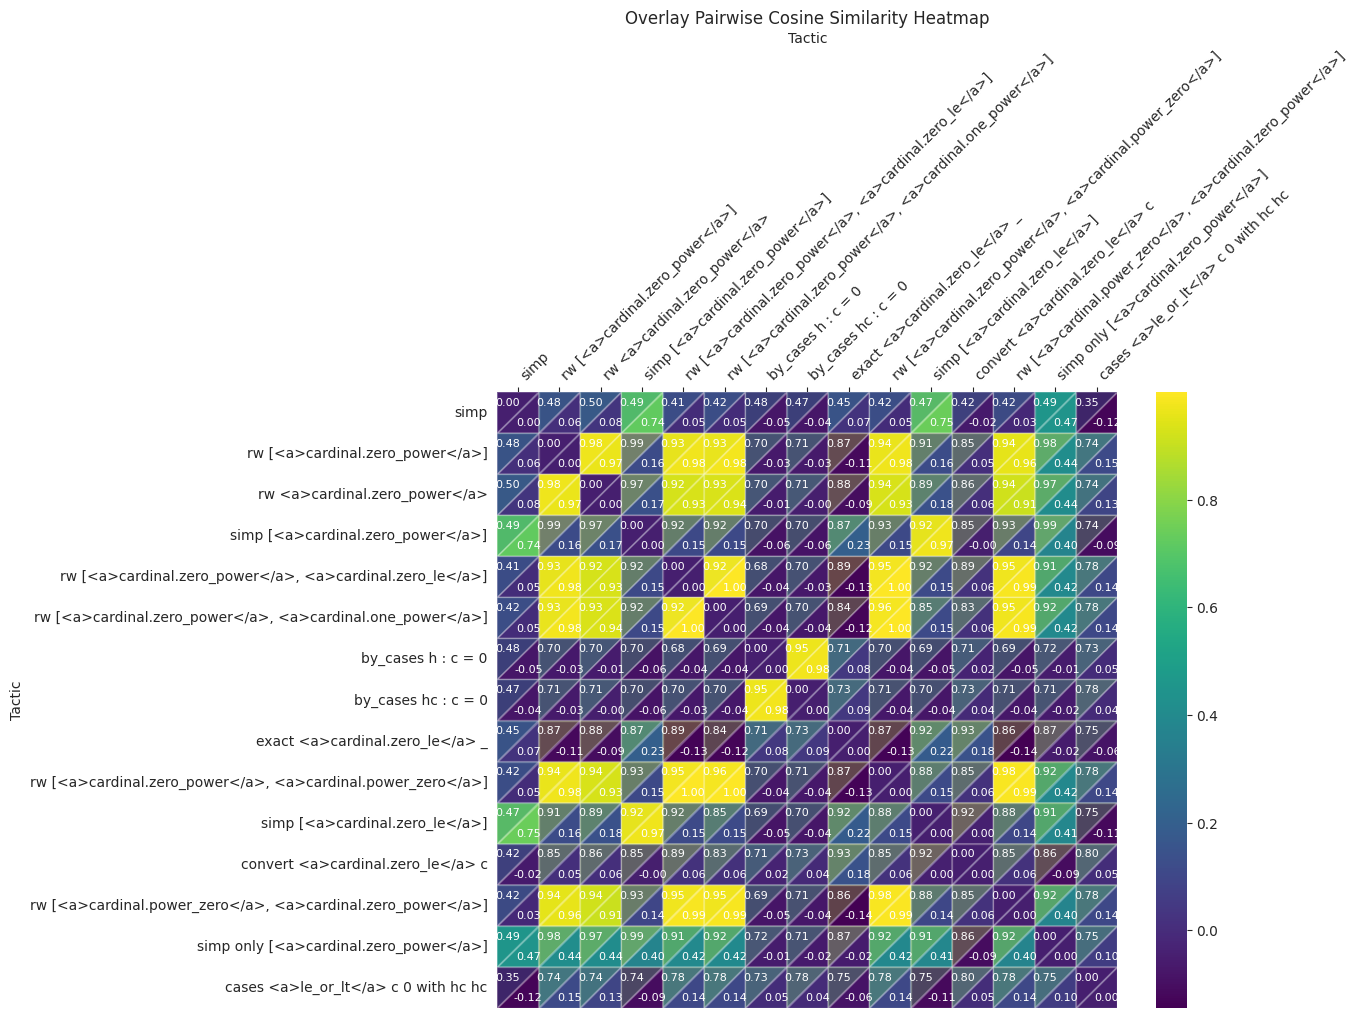

In [96]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

def <a>computation.head</a> (c : computation α) : option α := c.1.head

def <a>computation.destruct</a> (c : computation α) : α ⊕ computation α :=
match c.1 0 with
| none := sum.inr (tail c)
| some a := sum.inl a
end

def <a>stream.corec_on</a> (a : α) (f : α → β) (g : α → α) : stream β :=
corec f g a

def <a>computation.rec_on</a> {C : computation α → Sort v} (s : computation α)
  (h1 : ∀ a, C (return a)) (h2 : ∀ s, C (think s)) : C s := begin
  induction H : destruct s with v v,
  { rw destruct_eq_ret H, apply h1 },
  { cases v with a s', rw destruct_eq_think H, apply h2 }
end

def <a>computation.return</a> (a : α) : computation α := ⟨stream.const (some a), λ n a', id⟩

@[simp] theorem <a>computation.destruct_ret</a> (a : α) : destruct (return a) = sum.inl a

def <a>computation.corec.F</a> (f : β → α ⊕ β) : α ⊕ β → option α × (α ⊕ β)
| (sum.inl a) := (some a, sum.inl a)
| (sum.inr b) := (match f b with
  | sum.inl a := some a
  | sum.inr b' := none
  end, f b)

theorem <a>stream.core

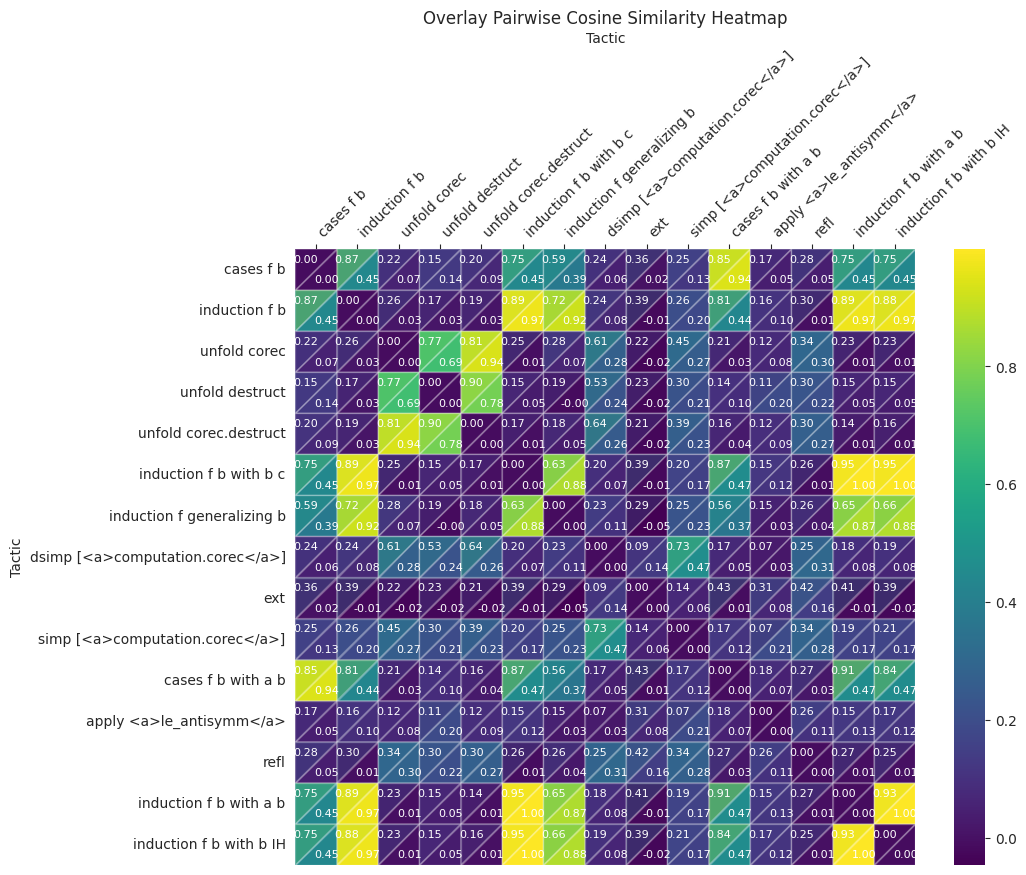

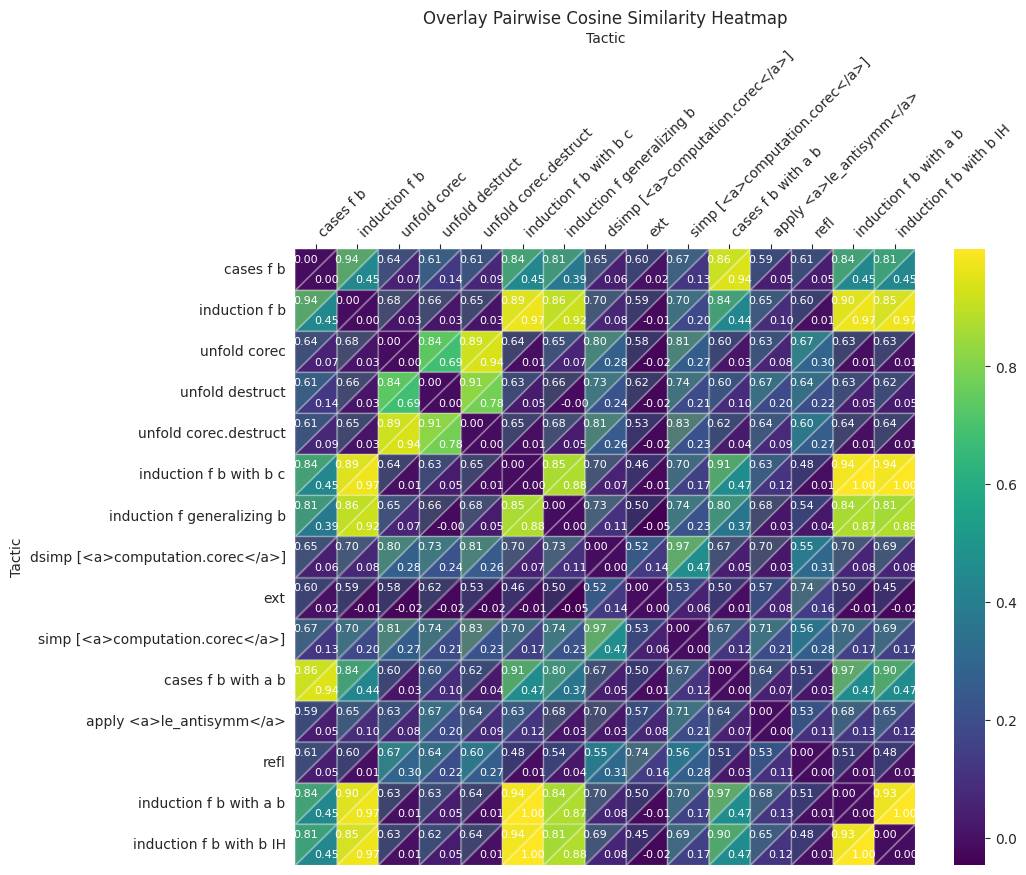

In [43]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

theorem <a>list.index_of_lt_length</a> {a} {l : list α} : index_of a l < length l ↔ a ∈ l

@[simp] lemma <a>list.length_attach</a> (L : list α) : L.attach.length = L.length

lemma <a>list.inth_eq_nth_le</a> {n : ℕ} (hn : n < l.length) : l.inth n = l.nth_le n hn

lemma <a>list.take_append_of_le_length</a> {l₁ l₂ : list α} {n : ℕ} (h : n ≤ l₁.length) :
  (l₁ ++ l₂).take n = l₁.take n

theorem <a>list.mem_iff_nth_le</a> {a} {l : list α} : a ∈ l ↔ ∃ n h, nth_le l n h = a

theorem <a>list.index_of_eq_length</a> {a : α} {l : list α} : index_of a l = length l ↔ a ∉ l

theorem <a>list.nth_le_of_mem</a> : ∀ {a} {l : list α}, a ∈ l → ∃ n h, nth_le l n h = a

theorem <a>list.index_of_le_length</a> {a : α} {l : list α} : index_of a l ≤ length l

lemma <a>list.inth_eq_default</a> {n : ℕ} (hn : l.length ≤ n) : l.inth n = default

@[simp] theorem <a>list.take_left</a> : ∀ l₁ l₂ : list α, take (length l₁) (l₁ ++ l₂) = l₁

@[ext]
theorem <a>list.ext</a> : ∀ {l₁ l₂ : list α}, (∀n, nth l₁ n = nth l₂ n) →

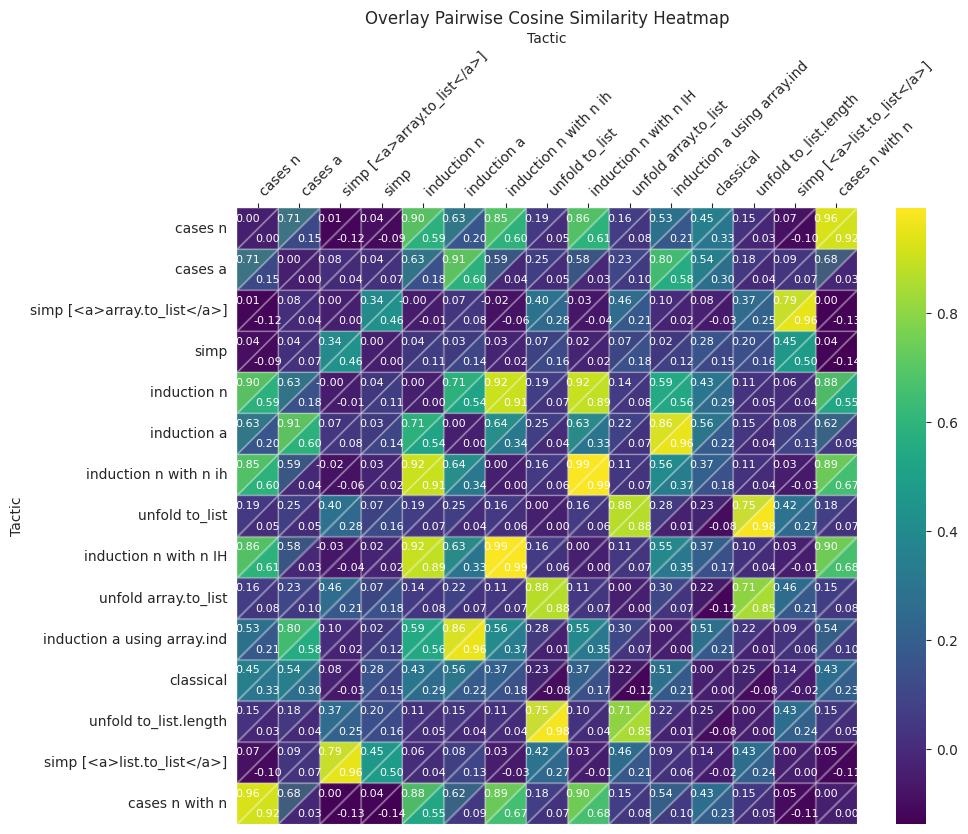

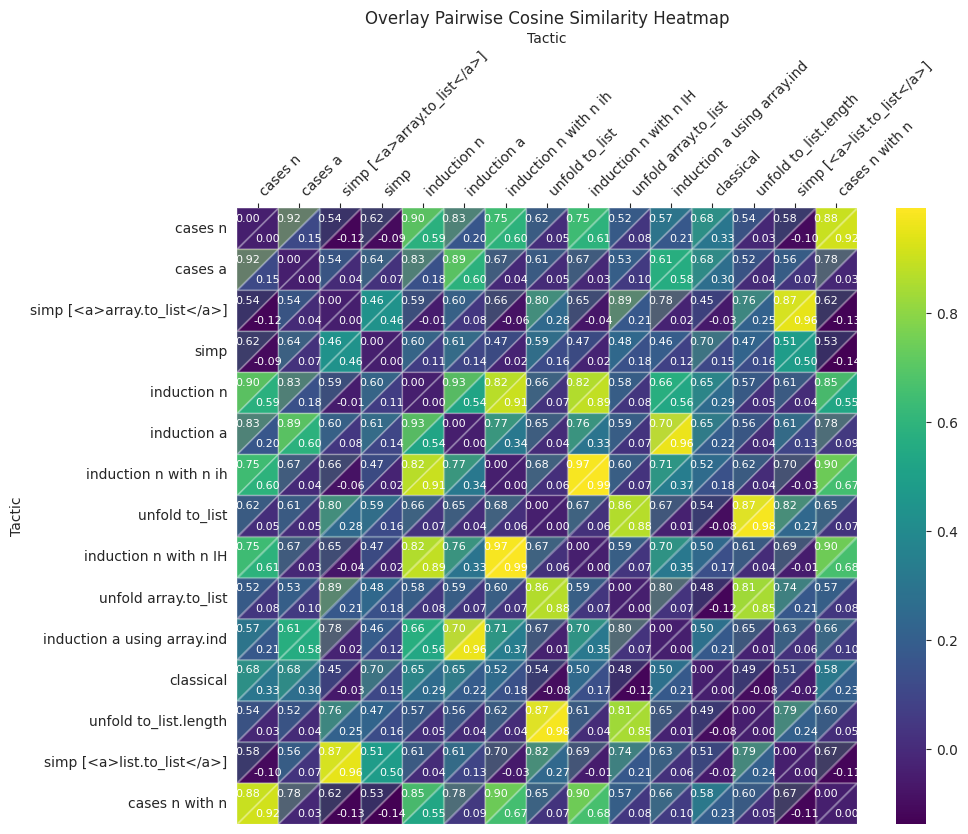

In [40]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

theorem <a>list.index_of_lt_length</a> {a} {l : list α} : index_of a l < length l ↔ a ∈ l

@[simp] lemma <a>list.length_attach</a> (L : list α) : L.attach.length = L.length

lemma <a>list.inth_eq_nth_le</a> {n : ℕ} (hn : n < l.length) : l.inth n = l.nth_le n hn

lemma <a>list.take_append_of_le_length</a> {l₁ l₂ : list α} {n : ℕ} (h : n ≤ l₁.length) :
  (l₁ ++ l₂).take n = l₁.take n

theorem <a>list.mem_iff_nth_le</a> {a} {l : list α} : a ∈ l ↔ ∃ n h, nth_le l n h = a

theorem <a>list.index_of_eq_length</a> {a : α} {l : list α} : index_of a l = length l ↔ a ∉ l

theorem <a>list.nth_le_of_mem</a> : ∀ {a} {l : list α}, a ∈ l → ∃ n h, nth_le l n h = a

theorem <a>list.index_of_le_length</a> {a : α} {l : list α} : index_of a l ≤ length l

lemma <a>list.inth_eq_default</a> {n : ℕ} (hn : l.length ≤ n) : l.inth n = default

@[simp] theorem <a>list.take_left</a> : ∀ l₁ l₂ : list α, take (length l₁) (l₁ ++ l₂) = l₁

@[ext]
theorem <a>list.ext</a> : ∀ {l₁ l₂ : list α}, (∀n, nth l₁ n = nth l₂ n) →

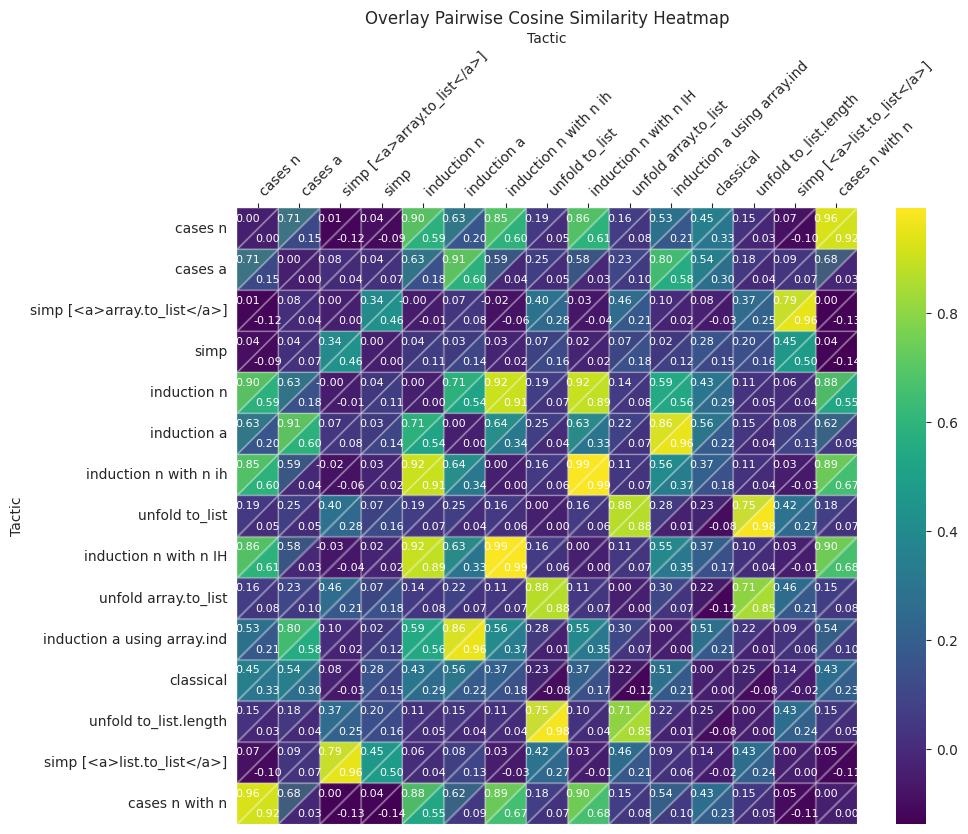

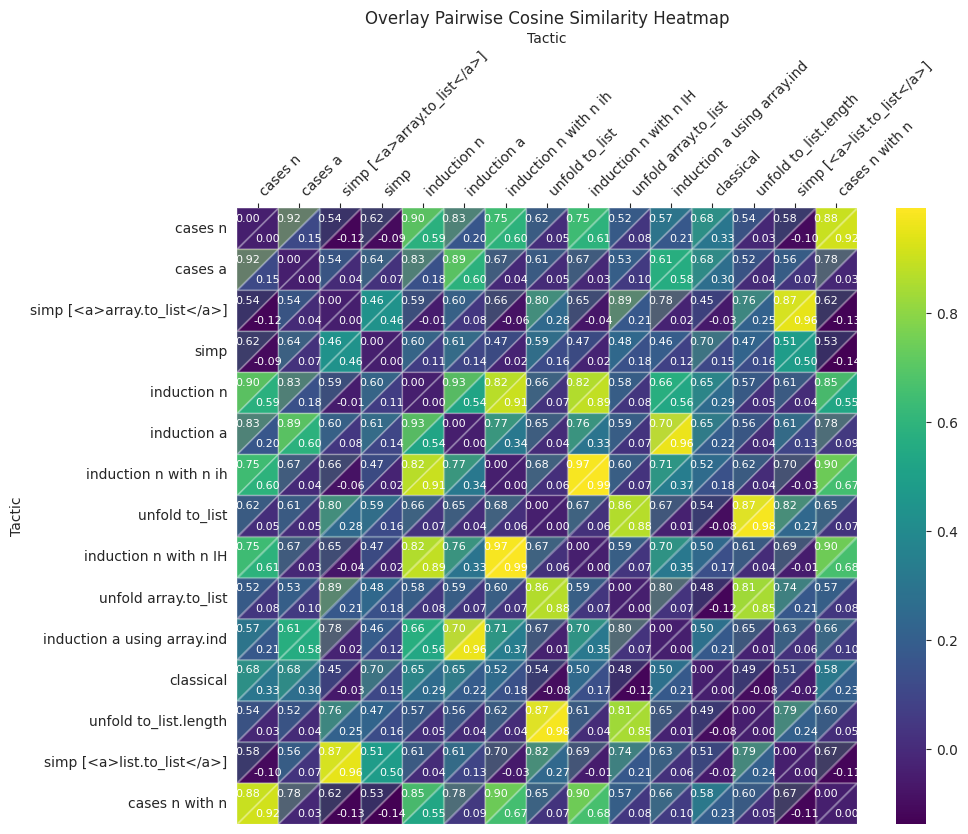

In [40]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)

theorem <a>cau_seq.const_lim_zero</a> {x : β} : lim_zero (const x) ↔ x = 0

lemma <a>cau_seq.lim_mul</a> (f : cau_seq β abv) (x : β) : lim f * x = lim (f * const abv x)

theorem <a>cau_seq.lim_zero_sub_rev</a> {f g : cau_seq β abv} (hfg : lim_zero (f - g)) : lim_zero (g - f)

lemma <a>cau_seq.equiv_lim</a> (s : cau_seq β abv) : s ≈ const abv (lim s)

lemma <a>cau_seq.lim_mul_lim</a> (f g : cau_seq β abv) : lim f * lim g = lim (f * g)

lemma <a>cau_seq.lim_neg</a> (f : cau_seq β abv) : lim (-f) = -lim f

@[simp] lemma <a>cau_seq.lim_const</a> (x : β) : lim (const abv x) = x

theorem <a>cau_seq.add_lim_zero</a> {f g : cau_seq β abv}
  (hf : lim_zero f) (hg : lim_zero g) : lim_zero (f + g)

theorem <a>cau_seq.not_lim_zero_of_pos</a> {f : cau_seq α abs} : pos f → ¬ lim_zero f

theorem <a>cau_seq.mul_lim_zero_left</a> {f} (g : cau_seq β abv)
  (hg : lim_zero f) : lim_zero (f * g)

theorem <a>cau_seq.mul_lim_zero_right</a> (f : cau_seq β abv) {g}
  (hg : lim_zero g) : lim_zero (f * g)

lemma

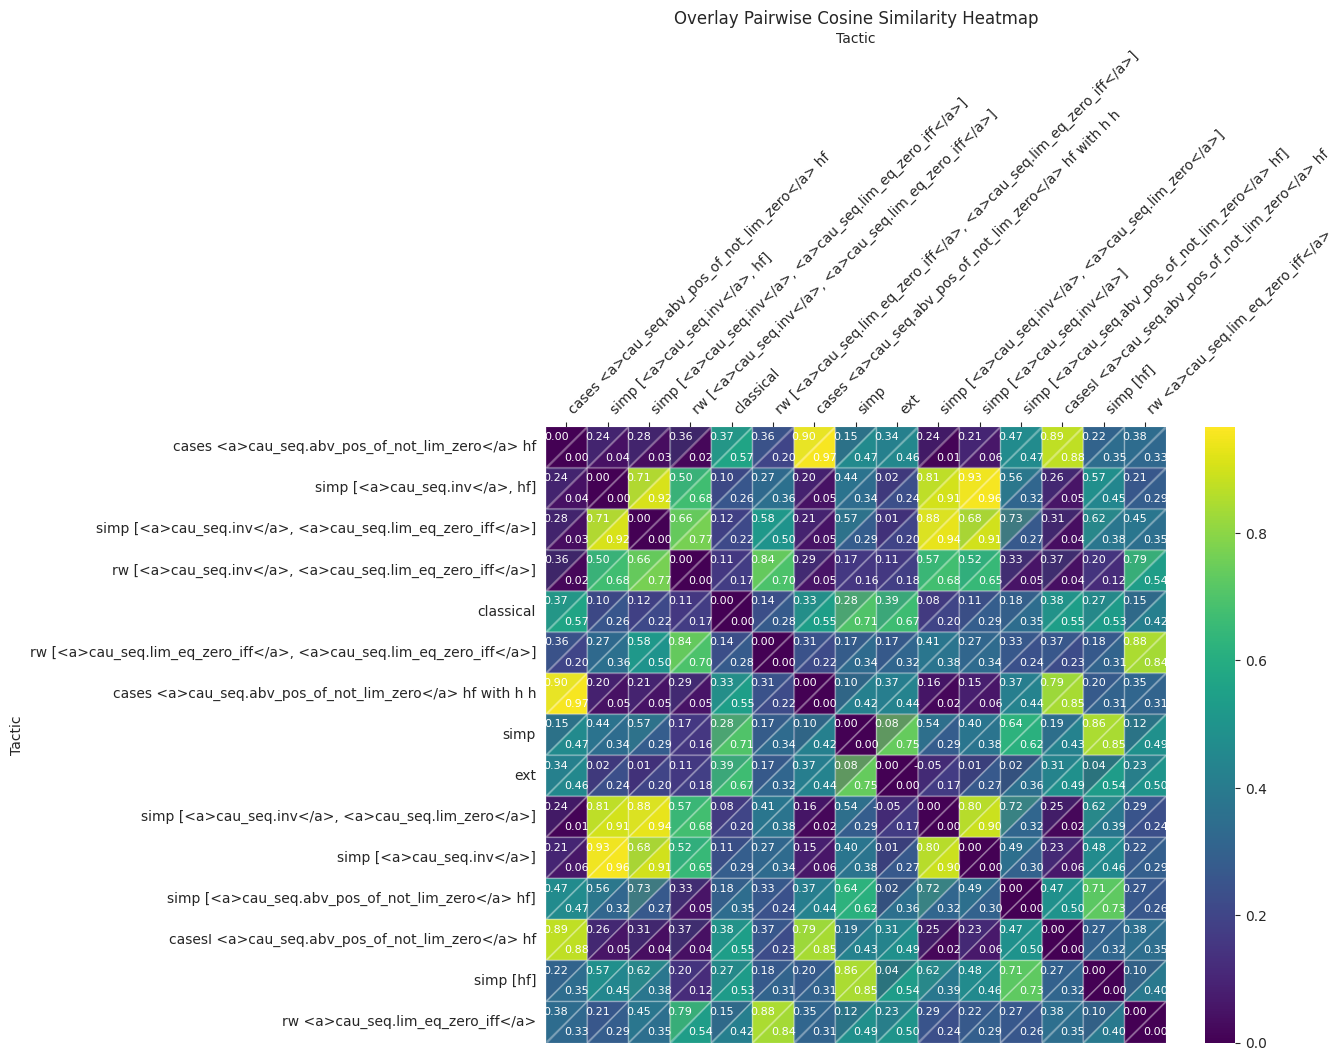

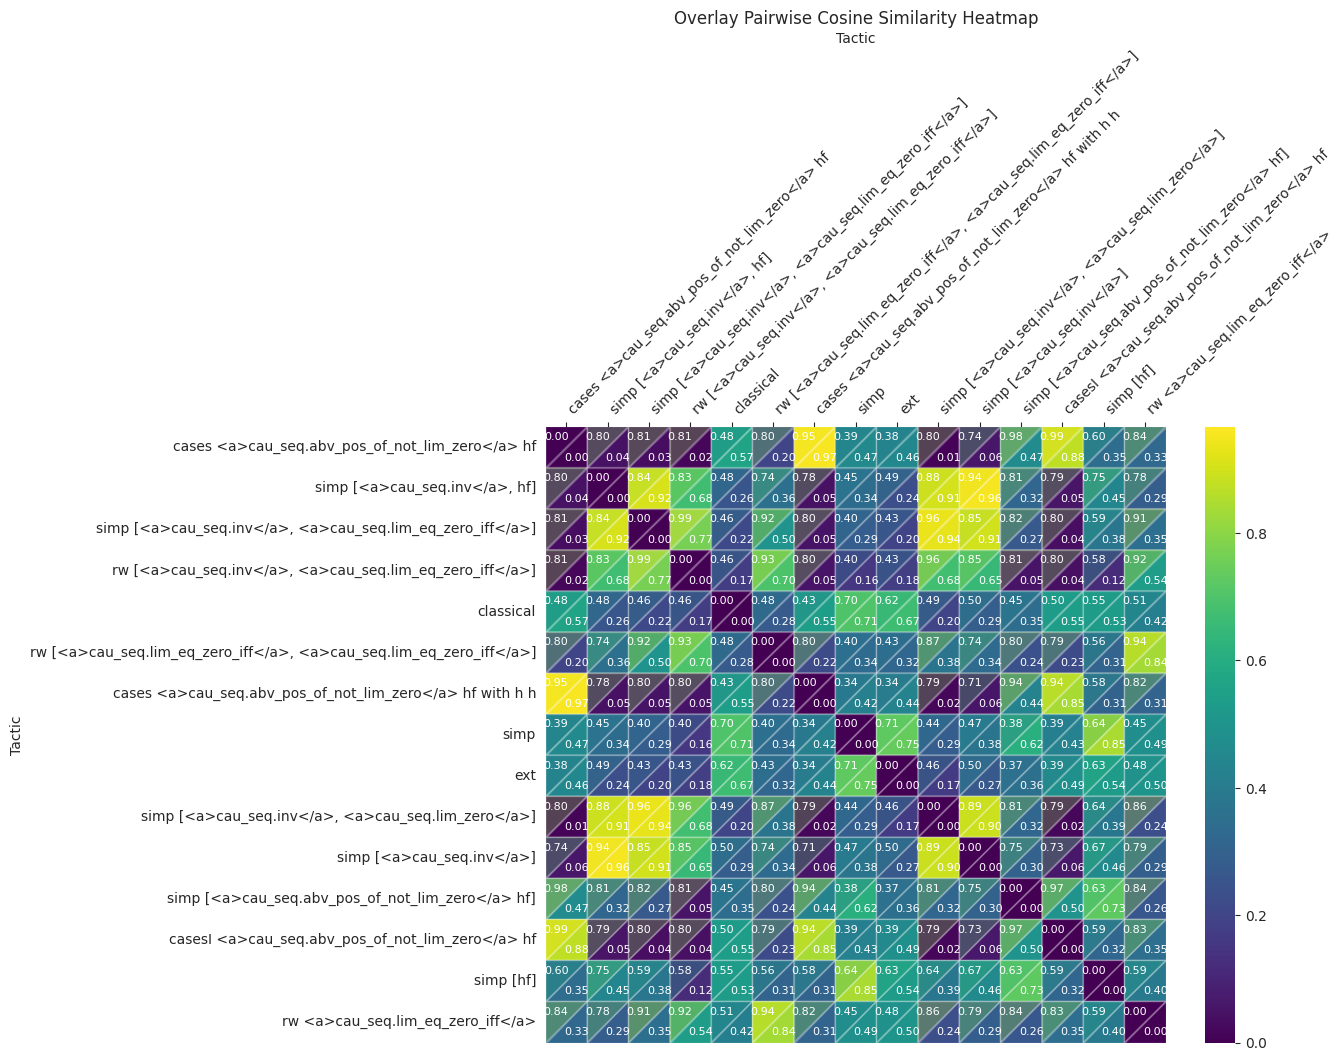

In [33]:
print (node.data['augmented_state'])
plot_overlay(start, end, separate_cosine_sim, combined_cosine_sim)
plot_overlay(start, end, autoencsim, combined_cosine_sim)